In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from glob import glob
import re
import nltk

# BOW, DCTM, and TDIDF

In [2]:
CORPUS = pd.read_csv("/kaggle/input/notebooks/isabellouisedelgado/text-as-data-final-project-corpus/GothicNovels_CORPUS.csv").set_index('book_id')


In [3]:
OHCO = ['book_id', 'chap_num', 'para_num', 'sent_num', 'token_num']
bags = dict(
    SENTS = OHCO[:4],
    PARAS = OHCO[:3],
    CHAPS = OHCO[:2],
    BOOKS = OHCO[:1]
)

bag = 'CHAPS'

In [4]:
bags[bag]+['term_str']

['book_id', 'chap_num', 'term_str']

In [5]:
BOW = CORPUS.groupby(bags[bag]+['term_str']).term_str.count().to_frame('n') 
BOW.head()

n
book_id chap_num term_str   
43      8        case      1
                 dr        1
                 full      1
                 henry     1
                 jekyll    1

In [6]:
DTCM = BOW.n.unstack(fill_value=0)
DTCM.head(10)

term_str          1  10  100  1018  1030  10th  11  1140  11th  12  ...  \
book_id chap_num                                                    ...   
43      8         0   0    0     0     0     0   0     0     0   0  ...   
        9         0   0    0     0     0     0   0     0     0   0  ...   
        10        0   0    0     0     0     0   0     0     0   0  ...   
        11        0   0    0     0     0     0   0     0     0   0  ...   
        12        0   0    0     0     0     0   0     0     0   0  ...   
        13        0   0    0     0     0     0   0     0     0   0  ...   
        14        0   0    0     0     0     0   0     0     0   0  ...   
        15        0   0    0     0     0     0   0     0     0   0  ...   
        16        0   0    0     0     0     1   0     0     0   0  ...   
175     1         2   0    0     0     0     0   0     0     0   0  ...   

term_str          zoöphagy  zurich  à  æneis  æra  æt  ætat  æther  état  \
book_id chap_num                                                           
43      8                0       0  0      0    0   0     0      0     0   
        9                0       0  0      0    0   0     0      0     0   
        10               0       0  1      0    0   0     0      0     0   
        11               0       0  0      0    0   0     0      0     0   
        12               0       0  0      0    0   0     0      0     0   
        13               0       0  0      0    0   0     0      0     0   
        14               0       0  0      0    0   0     0      0     0   
        15               0       0  0      0    0   0     0      0     0   
        16               0       0  0      0    0   0     0      0     0   
175     1                0       0  0      0    0   0     0      0     0   

term_str          œdipus  
book_id chap_num          
43      8              0  
        9              0  
        10             0  
        11             0  
        12             0  
        13             0  
        14             0  
        15             0  
        16             0  
175     1              0  

[10 rows x 23657 columns]

In [7]:
tf_method = 'double_norm'         # sum, max, log, double_norm, raw, binary
tf_norm_k = .5            # only used for double_norm
idf_method = 'smooth'   # standard, max, smooth
gradient_cmap = 'YlGnBu'

In [8]:
print('TF method:', tf_method)

if tf_method == 'sum':
    TF = DTCM.T / DTCM.T.sum()

elif tf_method == 'smooth':
    TF = (DTCM.T / DTCM.T.sum()) + 1

elif tf_method == 'max':
    TF = DTCM.T / DTCM.T.max()
    
elif tf_method == 'log':
    TF = np.log2(1 + DTCM.T)
    
elif tf_method == 'raw':
    TF = DTCM.T
    
elif tf_method == 'double_norm':
    TF = ((DTCM.T + .5) / (DTCM.T.max() + .5)) + .5
    
elif tf_method == 'binary':
    TF = DTCM.T.astype('bool').astype('int')
    
TF = TF.T

TF method: double_norm


In [9]:
TF.head()

term_str                 1        10       100      1018      1030      10th  \
book_id chap_num                                                               
43      8         0.700000  0.700000  0.700000  0.700000  0.700000  0.700000   
        9         0.503279  0.503279  0.503279  0.503279  0.503279  0.503279   
        10        0.502625  0.502625  0.502625  0.502625  0.502625  0.502625   
        11        0.510989  0.510989  0.510989  0.510989  0.510989  0.510989   
        12        0.503984  0.503984  0.503984  0.503984  0.503984  0.503984   

term_str                11      1140      11th        12  ...  zoöphagy  \
book_id chap_num                                          ...             
43      8         0.700000  0.700000  0.700000  0.700000  ...  0.700000   
        9         0.503279  0.503279  0.503279  0.503279  ...  0.503279   
        10        0.502625  0.502625  0.502625  0.502625  ...  0.502625   
        11        0.510989  0.510989  0.510989  0.510989  ...  0.510989   
        12        0.503984  0.503984  0.503984  0.503984  ...  0.503984   

term_str            zurich         à     æneis       æra        æt      ætat  \
book_id chap_num                                                               
43      8         0.700000  0.700000  0.700000  0.700000  0.700000  0.700000   
        9         0.503279  0.503279  0.503279  0.503279  0.503279  0.503279   
        10        0.502625  0.507874  0.502625  0.502625  0.502625  0.502625   
        11        0.510989  0.510989  0.510989  0.510989  0.510989  0.510989   
        12        0.503984  0.503984  0.503984  0.503984  0.503984  0.503984   

term_str             æther      état    œdipus  
book_id chap_num                                
43      8         0.700000  0.700000  0.700000  
        9         0.503279  0.503279  0.503279  
        10        0.502625  0.502625  0.502625  
        11        0.510989  0.510989  0.510989  
        12        0.503984  0.503984  0.503984  

[5 rows x 23657 columns]

In [10]:
DF = DTCM.astype('bool').sum() 
DF

term_str
1         17
10         6
100        1
1018       1
1030       1
          ..
æt         1
ætat       1
æther      3
état       1
œdipus     1
Length: 23657, dtype: int64

In [11]:
N = DTCM.shape[0]

In [12]:
print('IDF method:', idf_method)

if idf_method == 'standard':
    IDF = np.log2(N / DF)

elif idf_method == 'max':
    IDF = np.log2(DF.max() / DF) 

elif idf_method == 'plus':
    IDF = np.log2(N / DF) + 1

# This is what SciKit Learn uses
elif idf_method == 'smooth':
    IDF = np.log2((1 + N) / (1 + DF)) + 1

IDF method: smooth


In [13]:
IDF

term_str
1         3.748938
10        5.111508
100       6.918863
1018      6.918863
1030      6.918863
            ...   
æt        6.918863
ætat      6.918863
æther     5.918863
état      6.918863
œdipus    6.918863
Length: 23657, dtype: float64

In [14]:
TFIDF = TF * IDF
TFIDF.head()

term_str                 1        10       100      1018      1030      10th  \
book_id chap_num                                                               
43      8         2.624257  3.578056  4.843204  4.843204  4.843204  4.843204   
        9         1.886761  2.572513  3.482116  3.482116  3.482116  3.482116   
        10        1.884309  2.569170  3.477591  3.477591  3.477591  3.477591   
        11        1.915666  2.611925  3.535463  3.535463  3.535463  3.535463   
        12        1.889405  2.576119  3.486997  3.486997  3.486997  3.486997   

term_str                11      1140      11th        12  ...  zoöphagy  \
book_id chap_num                                          ...             
43      8         3.578056  4.843204  4.433731  3.578056  ...  4.843204   
        9         2.572513  3.482116  3.187717  2.572513  ...  3.482116   
        10        2.569170  3.477591  3.183575  2.569170  ...  3.477591   
        11        2.611925  3.535463  3.236554  2.611925  ...  3.535463   
        12        2.576119  3.486997  3.192185  2.576119  ...  3.486997   

term_str            zurich         à     æneis       æra        æt      ætat  \
book_id chap_num                                                               
43      8         4.843204  3.917855  4.843204  4.843204  4.843204  4.843204   
        9         3.482116  2.816818  3.482116  3.482116  3.482116  3.482116   
        10        3.477591  2.842538  3.477591  3.477591  3.477591  3.477591   
        11        3.535463  2.859972  3.535463  3.535463  3.535463  3.535463   
        12        3.486997  2.820766  3.486997  3.486997  3.486997  3.486997   

term_str             æther      état    œdipus  
book_id chap_num                                
43      8         4.143204  4.843204  4.843204  
        9         2.978838  3.482116  3.482116  
        10        2.974967  3.477591  3.477591  
        11        3.024474  3.535463  3.535463  
        12        2.983013  3.486997  3.486997  

[5 rows x 23657 columns]

## FINAL BOW, DTCM, and TFIDF tables

In [15]:
BOW['tfidf'] = TFIDF.stack()
BOW.to_csv("GothicNovels_BOW.csv")
BOW

n     tfidf
book_id  chap_num term_str              
43       8        case       1  2.186938
                  dr         1  2.980351
                  full       1  2.086145
                  henry      1  3.956629
                  jekyll     1  5.223832
...                         ..       ...
20180856 9        yes        2  0.775931
                  you       74  0.801915
                  young      1  0.843781
                  your      15  0.605825
                  yourself   1  1.003954

[157443 rows x 2 columns]

In [16]:
DTCM.to_csv("GothicNovels_DTCM.csv")

In [17]:
TFIDF.to_csv("GothicNovels_TFIDF.csv")
TFIDF

term_str                  1        10       100      1018      1030      10th  \
book_id  chap_num                                                               
43       8         2.624257  3.578056  4.843204  4.843204  4.843204  4.843204   
         9         1.886761  2.572513  3.482116  3.482116  3.482116  3.482116   
         10        1.884309  2.569170  3.477591  3.477591  3.477591  3.477591   
         11        1.915666  2.611925  3.535463  3.535463  3.535463  3.535463   
         12        1.889405  2.576119  3.486997  3.486997  3.486997  3.486997   
...                     ...       ...       ...       ...       ...       ...   
20180856 5         1.879570  2.562709  3.468845  3.468845  3.468845  3.468845   
         6         1.885089  2.570234  3.479032  3.479032  3.479032  3.479032   
         7         1.879926  2.563194  3.469503  3.469503  3.469503  3.469503   
         8         1.882932  2.567293  3.475050  3.475050  3.475050  3.475050   
         9         1.880686  2.564231  3.470906  3.470906  3.470906  3.470906   

term_str                 11      1140      11th        12  ...  zoöphagy  \
book_id  chap_num                                          ...             
43       8         3.578056  4.843204  4.433731  3.578056  ...  4.843204   
         9         2.572513  3.482116  3.187717  2.572513  ...  3.482116   
         10        2.569170  3.477591  3.183575  2.569170  ...  3.477591   
         11        2.611925  3.535463  3.236554  2.611925  ...  3.535463   
         12        2.576119  3.486997  3.192185  2.576119  ...  3.486997   
...                     ...       ...       ...       ...  ...       ...   
20180856 5         2.562709  3.468845  3.175568  2.562709  ...  3.468845   
         6         2.570234  3.479032  3.184893  2.570234  ...  3.479032   
         7         2.563194  3.469503  3.176170  2.563194  ...  3.469503   
         8         2.567293  3.475050  3.181248  2.567293  ...  3.475050   
         9         2.564231  3.470906  3.177454  2.564231  ...  3.470906   

term_str             zurich         à     æneis       æra        æt      ætat  \
book_id  chap_num                                                               
43       8         4.843204  3.917855  4.843204  4.843204  4.843204  4.843204   
         9         3.482116  2.816818  3.482116  3.482116  3.482116  3.482116   
         10        3.477591  2.842538  3.477591  3.477591  3.477591  3.477591   
         11        3.535463  2.859972  3.535463  3.535463  3.535463  3.535463   
         12        3.486997  2.820766  3.486997  3.486997  3.486997  3.486997   
...                     ...       ...       ...       ...       ...       ...   
20180856 5         3.468845  2.821312  3.468845  3.468845  3.468845  3.468845   
         6         3.479032  2.814323  3.479032  3.479032  3.479032  3.479032   
         7         3.469503  2.806614  3.469503  3.469503  3.469503  3.469503   
         8         3.475050  2.811102  3.475050  3.475050  3.475050  3.475050   
         9         3.470906  2.807749  3.470906  3.470906  3.470906  3.470906   

term_str              æther      état    œdipus  
book_id  chap_num                                
43       8         4.143204  4.843204  4.843204  
         9         2.978838  3.482116  3.482116  
         10        2.974967  3.477591  3.477591  
         11        3.024474  3.535463  3.535463  
         12        2.983013  3.486997  3.486997  
...                     ...       ...       ...  
20180856 5         2.967484  3.468845  3.468845  
         6         2.976199  3.479032  3.479032  
         7         2.968047  3.469503  3.469503  
         8         2.972792  3.475050  3.475050  
         9         2.969247  3.470906  3.470906  

[120 rows x 23657 columns]

# Adding DFIDF to VOCAB table and getting top 20 words

In [18]:
VOCAB = pd.read_csv("/kaggle/input/notebooks/isabellouisedelgado/text-as-data-final-project-corpus/GothicNovels_VOCAB.csv").set_index('term_str')

In [19]:
VOCAB['dfidf'] = DF * IDF
VOCAB

,n,n_chars,p,i,max_pos,max_pos_group,stop,stem_porter,dfidf
term_str,,,,,,,,,
1,31,1,0.000036,14.775338,CD,CD,0,1,63.731950
10,8,2,0.000009,16.729534,CD,CD,0,10,30.669050
100,1,3,0.000001,19.729534,CD,CD,0,100,6.918863
1018,1,4,0.000001,19.729534,CD,CD,0,1018,6.918863
1030,2,4,0.000002,18.729534,CD,CD,0,1030,6.918863
...,...,...,...,...,...,...,...,...,...
æt,1,2,0.000001,19.729534,NNP,NN,0,æt,6.918863
ætat,1,4,0.000001,19.729534,VBZ,VB,0,ætat,6.918863
æther,6,5,0.000007,17.144572,NN,NN,0,æther,17.756590


In [20]:
VOCAB.sort_values(by='dfidf', ascending=False).head(20)

,n,n_chars,p,i,max_pos,max_pos_group,stop,stem_porter,dfidf
term_str,,,,,,,,,
tell,706,4,0.000812,10.266010,VB,VB,0,tell,127.003903
take,569,4,0.000655,10.577250,VB,VB,0,take,127.003903
old,725,3,0.000834,10.227697,JJ,JJ,0,old,127.003903
put,378,3,0.000435,11.167292,VBD,VB,0,put,127.003903
perhaps,444,7,0.000511,10.935119,RB,RB,0,perhap,127.003903
gave,471,4,0.000542,10.849951,VBD,VB,0,gave,127.003903
suddenly,312,8,0.000359,11.444132,RB,RB,0,suddenli,126.996174
passed,559,6,0.000643,10.602830,VBD,VB,0,pass,126.996174
far,406,3,0.000467,11.064199,RB,RB,0,far,126.995423


In [21]:
VOCAB.to_csv("GothicNovel_VOCAB2.csv")

# Reduced and Normalized TFIDF_L2

In [22]:
from numpy.linalg import norm
from scipy.spatial.distance import pdist

In [23]:
V = TFIDF.astype(bool).sum().to_frame('df') #TFIDF_BAG.mean().to_frame('mean_tfidf')
V.index.name = 'term_str'
N = len(TFIDF)
V['dp'] = V.df / N
V['di'] = np.log2(1/V.dp)
V['dh'] = V.dp * V.di
V.sample(5)

,df,dp,di,dh
term_str,,,,
coryat,120,1.0,0.0,0.0
dainty,120,1.0,0.0,0.0
18,120,1.0,0.0,0.0
brood,120,1.0,0.0,0.0
plated,120,1.0,0.0,0.0


In [24]:
sig_thresh = .125

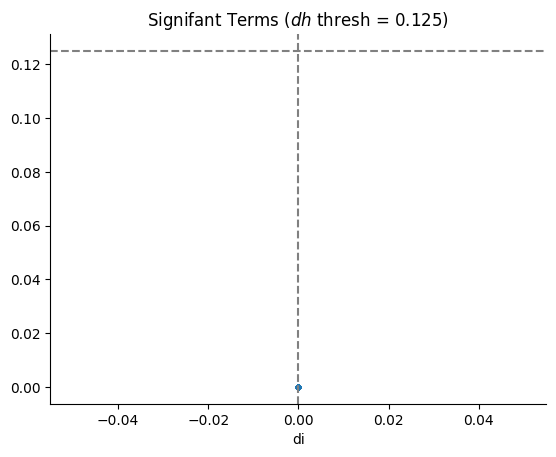

In [25]:
D = V.set_index('di').dh
ax = D.plot(style='.')
ax.axvline(D.idxmax(), ls='--', c='gray')
ax.axhline(sig_thresh, ls='--', c='gray')
sns.despine()
plt.title(f"Signifant Terms ($dh$ thresh = {sig_thresh})")
plt.show()